In [1]:
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import add_self_loops
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.model_selection import train_test_split

import os
import sys
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))

from utils.graph_utils import load_graph, save_graph
from utils.sample_scoring import process_and_save, do_radical_search, do_biological_logfc, do_std
from data_processing.network_generator import PatientNetworkGenerator, build_knn_graph_with_masks
from hetero_base_models.train_hybridkg import (compute_link_loss, 
                            split_edges,
                            evaluate,
                            train,
                            test,
                            build_x_dict,
                            set_seed
                            )
from hetero_base_models.utilities import (convert_to_hetero_data, 
                                          bridge_names_to_indices,
                                        assign_kg_by_EdgeScore,
                                        bridge_names_to_indices)
from hetero_base_models.base_models import get_model
import argparse

/opt/anaconda3/envs/firegnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [51]:
design = pd.read_csv("./data/ADNI/DXSUM_02Aug2025.csv")
design[design['PTID'] == "116_S_1249"][['PHASE', 'PTID', 'VISCODE', 'EXAMDATE', 'DIAGNOSIS']]
design['PTID'].unique()

<StringArray>
[ '011_S_0002',  '011_S_0003',  '011_S_0005',  '011_S_0008',  '022_S_0007',
  '100_S_0015',  '023_S_0030',  '023_S_0031',  '011_S_0016',  '011_S_0021',
 ...
 '116_S_10877', '067_S_10874', '010_S_10868', '405_S_10865', '405_S_10854',
 '305_S_10845', '010_S_10869', '116_S_10748', '022_S_10888', '022_S_10876']
Length: 3767, dtype: str

In [57]:
design_bl = design[design['VISCODE']=='bl'][['PHASE', 'PTID', 'VISCODE', 'EXAMDATE', 'DIAGNOSIS']]
design_bl = design_bl.set_index(design_bl['PTID'])
design_bl.index.name=None
design_bl

,PHASE,PTID,VISCODE,EXAMDATE,DIAGNOSIS
011_S_0002,ADNI1,011_S_0002,bl,2005-09-29,1.0
011_S_0003,ADNI1,011_S_0003,bl,2005-09-30,3.0
011_S_0005,ADNI1,011_S_0005,bl,2005-09-30,1.0
011_S_0008,ADNI1,011_S_0008,bl,2005-09-30,1.0
022_S_0007,ADNI1,022_S_0007,bl,2005-10-06,3.0
...,...,...,...,...,...
137_S_6883,ADNI3,137_S_6883,bl,NaN,2.0
137_S_6906,ADNI3,137_S_6906,bl,NaN,2.0
130_S_6390,ADNI3,130_S_6390,bl,NaN,1.0
153_S_7104,ADNI3,153_S_7104,bl,2022-12-01,1.0


In [ ]:
adni_exp = pd.read_csv("./data/ADNI/adni_exp_3cls.csv",index_col=0) xs
adni_exp

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZW10,ZWILCH,ZWINT,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
116_S_1249,3.651,2.2865,3.039,2.3395,2.783,2.25300,2.081,7.043,3.30950,2.202,...,5.748,3.77150,4.0365,4.353000,5.1763,1.9045,5.31750,9.2190,7.3010,5.7490
037_S_4410,3.183,2.1230,3.543,2.2085,2.383,2.37550,1.733,6.773,3.27625,2.317,...,5.974,4.17300,4.4415,4.520667,5.0964,1.9265,5.38800,8.3785,6.7580,6.0935
006_S_4153,3.278,2.3545,3.528,2.1745,2.593,2.46825,1.841,6.910,3.20875,2.540,...,5.119,3.91275,4.6210,4.230667,5.1143,2.2315,5.62800,9.1085,7.3365,5.2615
116_S_1232,3.371,2.3725,3.835,2.1545,2.570,2.51925,2.249,7.209,3.24950,2.559,...,4.904,3.73800,4.4435,4.050667,5.1520,2.0545,5.46300,9.3210,7.1685,4.7340
099_S_4205,3.358,2.3865,3.392,2.1720,2.660,2.39725,1.893,6.920,3.15425,2.347,...,5.533,3.94600,4.5215,4.639667,5.2103,2.0405,5.64750,9.0300,7.2025,5.4575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
009_S_2381,3.302,2.5075,3.524,2.2525,2.876,2.76275,2.089,6.805,3.09150,2.650,...,4.523,3.50150,4.4685,3.962333,5.0892,1.9320,5.44275,9.2900,6.7035,4.7915
053_S_4557,3.403,2.3090,3.515,2.3225,3.106,2.85125,2.102,7.265,3.27575,2.603,...,5.087,3.58325,4.1555,4.125667,5.0986,1.9445,5.14000,9.8090,7.2810,4.7055
073_S_4300,3.530,2.4155,3.651,2.0760,2.707,2.38325,2.092,7.375,3.26950,2.557,...,4.938,3.63450,4.5165,4.070333,5.1731,2.0795,5.38775,9.5215,6.9825,5.0785
041_S_4014,3.532,2.4545,3.609,2.3495,3.081,2.69125,2.024,7.257,3.11425,2.497,...,4.037,3.68525,4.0480,3.976333,4.8241,2.0075,5.05725,9.5810,6.6865,3.8660


In [62]:
design_3cls = design_bl.loc[design_bl.index.isin(adni_exp.index)]
design_3cls['DIAGNOSIS'].value_counts()

DIAGNOSIS
2.0    252
1.0    119
3.0      1
Name: count, dtype: int64

## Corrective (Clustering) results vs. Corrective Assignment results

In [23]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

def nhs_prediction_metrics(df):
    df['nhs_label'] = df['nhs_score'].apply(lambda x: 1 if x > 0.5 else 0)
    # 1. Define your ground truth and predictions
    y_true = df['label']
    y_pred = df['nhs_label']  # Binary labels (0 or 1)
    y_score = df['nhs_score'] # Continuous scores (0 to 1)

    # 2. Calculate Metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auroc = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)

    metrics = {
        "Accuracy": accuracy,
        'F1_score':f1,
        'AUROC':auroc,
        'AUPRC':auprc
    }
    return metrics

def calculate_source_ratio(df):
    results = []
    
    # Grouping by sample_id
    grouped = df.groupby('sample_id')
    
    for sample_id, group in grouped:
        num_c = (group['source_kg'] == 'c').sum()
        num_d = (group['source_kg'] == 'd').sum()
        
        
        # Calculate ratio (c / d)
        ratio = num_c / num_d if num_d > 0 else float('inf')
        
        results.append({
            'sample_id': sample_id,
            'c_count': num_c,
            'd_count': num_d,
            'c_d_ratio': ratio,
            #'nhs_score':group['nhs_score'].mean(),
            #'label': group['label'].iloc[0] # To verify alignment with original label
        })
    
    return pd.DataFrame(results)

In [16]:
adni_assignment = pd.read_csv("../results/HybridLP/adni/ecdf/gat/nhs_corrective_assignment/assignments_analysis.csv", index_col = 0)
geo_assignment = pd.read_csv("../results/HybridLP/geo/ecdf/gat/nhs_corrective_assignment/assignments_analysis.csv", index_col=0)

In [21]:
adni_nhs_metrics = nhs_prediction_metrics(adni_assignment)
adni_nhs_metrics

{'Accuracy': 0.5109489051094891,
 'F1_score': 0.5838509316770186,
 'AUROC': 0.566138698630137,
 'AUPRC': 0.590534941868386}

In [25]:
geo_nhs_metrics = nhs_prediction_metrics(geo_assignment)
geo_nhs_metrics

{'Accuracy': 0.9148936170212766,
 'F1_score': 0.9361702127659575,
 'AUROC': 0.9634449977365324,
 'AUPRC': 0.9755288648159347}

In [26]:
# Find all summary files across all experiments
def get_metrics(filedir="../results/HybridLP/*/*/*/*/summary.csv"):
    files = glob.glob(filedir)
    df_metrics = pd.concat([pd.read_csv(f) for f in files])
    df_melted = df_metrics.melt(
        id_vars=['dataset', 'scoring', 'model', 'modification'], 
        value_vars=['acc', 'f1_macro', 'auroc', 'auprc'],
        var_name='Metric', 
        value_name='Score'
    )
    
    return df_metrics, df_melted

In [32]:
df_metrics, df_melted = get_metrics("../results/HybridLP/*/*/*/*/summary.csv")
df = df_metrics[df_metrics['modification'] == 'nhs_corrective_assignment'][['dataset','modification', 'acc', 'f1_macro', 'auroc', 'auprc']]
df.columns = ['dataset','modification', 'Accuracy', 'F1_score', 'AUROC', 'AUPRC']
df.loc[len(df)] = {'dataset': 'geo', 'modification':'nhs_clustering', **geo_nhs_metrics}
df.loc[len(df)] = {'dataset': 'adni', 'modification':'nhs_clustering', **adni_nhs_metrics}
df

,dataset,modification,Accuracy,F1_score,AUROC,AUPRC
0,geo,nhs_corrective_assignment,0.901408,0.883251,0.901596,0.898038
0,adni,nhs_corrective_assignment,0.507246,0.494397,0.561655,0.633555
2,geo,nhs_clustering,0.914894,0.936170,0.963445,0.975529
3,adni,nhs_clustering,0.510949,0.583851,0.566139,0.590535


In [35]:
# melt df
df_melted = df.melt(
    id_vars = ['dataset', 'modification'],
    value_vars = ['Accuracy', 'F1_score', 'AUROC', 'AUPRC'],
    var_name = 'Metric',
    value_name = 'Score'
)
df_melted

,dataset,modification,Metric,Score
0,geo,nhs_corrective_assignment,Accuracy,0.901408
1,adni,nhs_corrective_assignment,Accuracy,0.507246
2,geo,nhs_clustering,Accuracy,0.914894
3,adni,nhs_clustering,Accuracy,0.510949
4,geo,nhs_corrective_assignment,F1_score,0.883251
5,adni,nhs_corrective_assignment,F1_score,0.494397
6,geo,nhs_clustering,F1_score,0.936170
7,adni,nhs_clustering,F1_score,0.583851
8,geo,nhs_corrective_assignment,AUROC,0.901596
9,adni,nhs_corrective_assignment,AUROC,0.561655


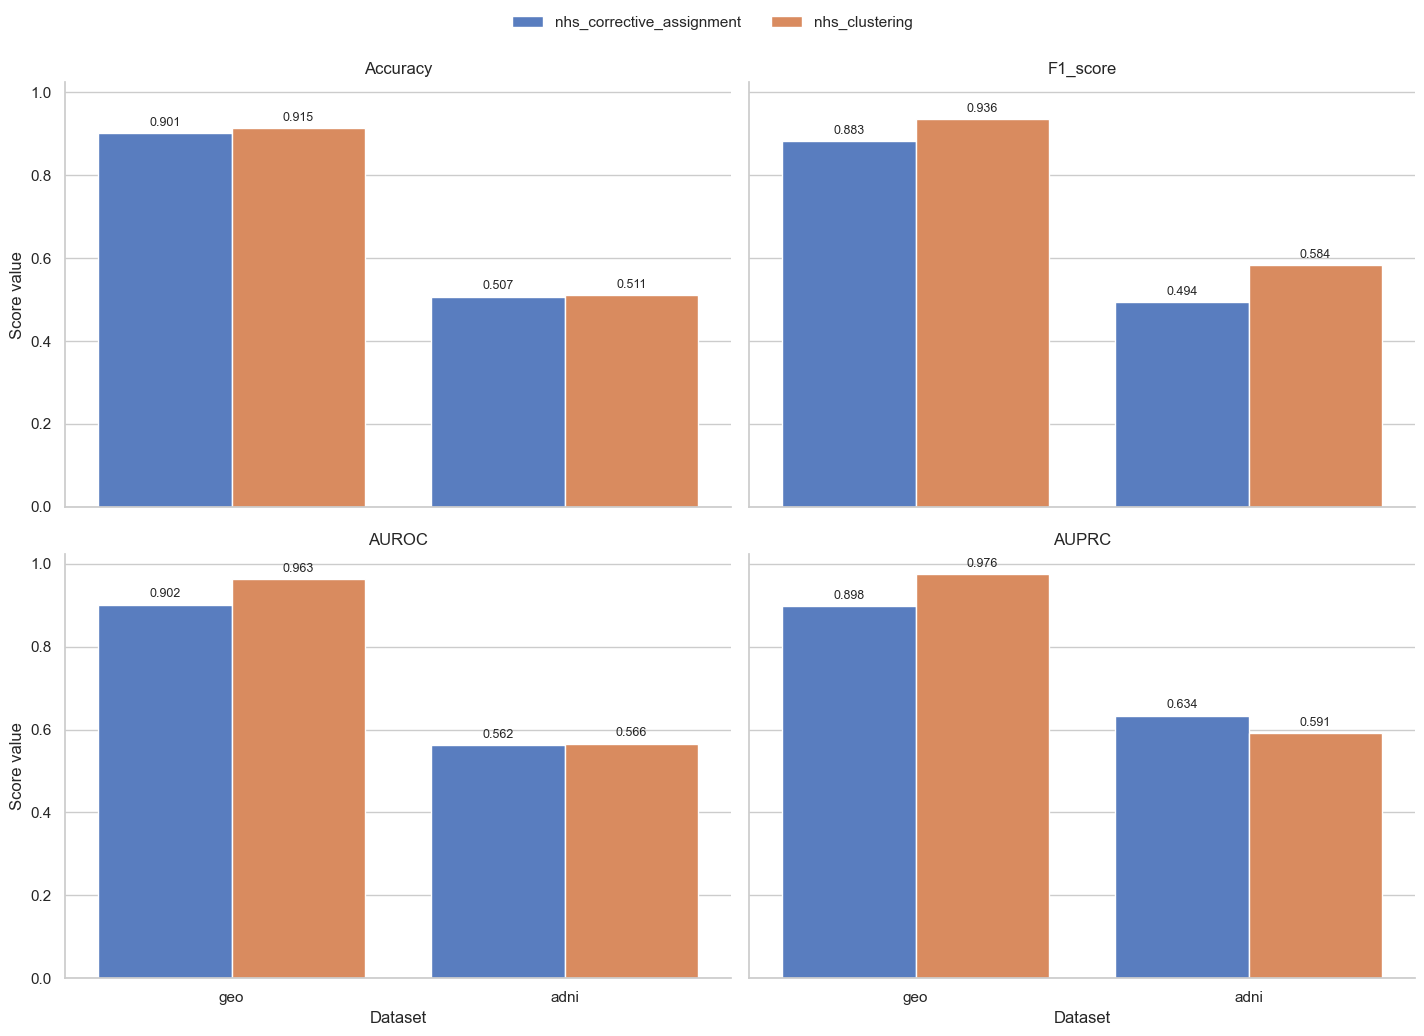

In [39]:
sns.set_theme(style="whitegrid")

# catplot: separate plots fro each metric
g = sns.catplot(
    data=df_melted,
    kind='bar',
    x='dataset',
    y='Score',
    hue='modification',
    col='Metric',
    col_wrap=2,
    palette='muted',
    height=5,
    aspect=1.2
)
g.set_axis_labels("Dataset", "Score value")
g.set_titles("{col_name}")

# move legend place
#g.add_legend(title="Classification Step")
sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
# Add values above each bar
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()